# Auditoria del dataset persistido

Este notebook valida los datos ya insertados en PostgreSQL. No genera usuarios, habilidades ni resultados.

`dataset_generator.ipynb` prepara features para ML; este notebook valida la consistencia del dataset frente a `dataset_generation_strategy.md`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlalchemy as sa

DB_HOST = os.getenv('ATHENA_DB_HOST', '100.95.220.1')
DB_PORT = int(os.getenv('ATHENA_DB_PORT', '5432'))
DB_USER = os.getenv('ATHENA_DB_USER', 'admin')
DB_PASSWORD = os.getenv('ATHENA_DB_PASSWORD', 'password')
DB_NAME = os.getenv('ATHENA_DB_NAME', 'athena')

connection_url = (
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}'
    f'@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)
engine = sa.create_engine(connection_url, connect_args={'connect_timeout': 10})
OUTPUT_DIR = Path('../../Reports/dataset_validation').resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Output: {OUTPUT_DIR}')

Output: C:\Users\emanu\Documents\METODOLOGIA\Athena\Reports\dataset_validation


In [2]:
with engine.connect() as connection:
    connection.execute(sa.text('SELECT 1')).scalar_one()
    counts = pd.read_sql_query(sa.text('''
        SELECT 'area' AS tabla, COUNT(*) AS filas FROM area
        UNION ALL SELECT 'carrera', COUNT(*) FROM carrera
        UNION ALL SELECT 'habilidad', COUNT(*) FROM habilidad
        UNION ALL SELECT 'criterio', COUNT(*) FROM criterio
        UNION ALL SELECT 'usuario', COUNT(*) FROM usuario
        UNION ALL SELECT 'usuario_habilidad', COUNT(*) FROM usuario_habilidad
        UNION ALL SELECT 'resultado', COUNT(*) FROM resultado
    '''), connection)
display(counts)

,tabla,filas
0,area,3
1,carrera,66
2,habilidad,253
3,criterio,729
4,usuario,7997
5,usuario_habilidad,32936
6,resultado,7997


## Extraccion y recomputacion independiente

La consulta consolida criterios por habilidad y cumplimiento por usuario con `MAX`, cruza cada perfil con carreras de su misma area y vuelve a calcular el target.

In [3]:
QUERY_DATASET = '''
WITH requerimientos AS (
    SELECT
        ch.id_carrera,
        c.id_area AS area_carrera,
        c.nombre_carrera,
        ch.id_habilidad,
        COUNT(cr.id_criterio)::INTEGER AS complejidad_habilidad
    FROM carrera_habilidad ch
    JOIN carrera c ON c.id_carrera = ch.id_carrera
    LEFT JOIN criterio cr ON cr.id_habilidad = ch.id_habilidad
    GROUP BY ch.id_carrera, c.id_area, c.nombre_carrera, ch.id_habilidad
), perfil AS (
    SELECT
        uh.id_usuario,
        u.uuid_usuario,
        u.id_area AS area_usuario,
        uh.id_habilidad,
        MAX(uh.cumplimiento_criterio)::DOUBLE PRECISION AS cumplimiento_criterio
    FROM usuario_habilidad uh
    JOIN usuario u ON u.id_usuario = uh.id_usuario
    GROUP BY uh.id_usuario, u.uuid_usuario, u.id_area, uh.id_habilidad
), calculado AS (
    SELECT
        p.id_usuario, p.uuid_usuario, p.area_usuario AS id_area,
        r.id_carrera, r.nombre_carrera,
        COUNT(*)::INTEGER AS habilidades_requeridas,
        COUNT(pm.id_habilidad)::INTEGER AS habilidades_comunes,
        COALESCE(SUM(pm.cumplimiento_criterio), 0.0)::DOUBLE PRECISION AS suma_cumplimiento,
        COALESCE(SUM(r.complejidad_habilidad), 0)::INTEGER AS complejidad_requerida,
        COALESCE(SUM(CASE WHEN pm.id_habilidad IS NOT NULL THEN r.complejidad_habilidad ELSE 0 END), 0)::INTEGER AS complejidad_cumplida,
        COALESCE(SUM(pm.cumplimiento_criterio), 0.0) / NULLIF(COUNT(*), 0)::DOUBLE PRECISION AS target_calculado
    FROM perfil p
    JOIN requerimientos r ON r.area_carrera = p.area_usuario
    LEFT JOIN perfil pm
        ON pm.id_usuario = p.id_usuario
       AND pm.id_habilidad = r.id_habilidad
    GROUP BY p.id_usuario, p.uuid_usuario, p.area_usuario, r.id_carrera, r.nombre_carrera
)
SELECT
    c.*,
    res.porcentaje_coincidencia::DOUBLE PRECISION AS target_persistido,
    res.top,
    CASE
        WHEN c.uuid_usuario LIKE 'USER-%' THEN 'USER'
        WHEN c.uuid_usuario LIKE 'CROSS-%' THEN 'CROSS'
        WHEN c.uuid_usuario LIKE 'PERT-%' THEN 'PERT'
        WHEN c.uuid_usuario LIKE 'COMBO-%' THEN 'COMBO'
        ELSE 'OTRA'
    END AS estrategia
FROM calculado c
JOIN resultado res
    ON res.uuid_usuario = c.uuid_usuario
   AND res.id_carrera = c.id_carrera
ORDER BY c.id_usuario, c.id_carrera;
'''

with engine.connect() as connection:
    df = pd.read_sql_query(sa.text(QUERY_DATASET), connection)

if df.empty:
    raise ValueError('La consulta no devolvio registros.')

df['target_recalculado_2dp'] = np.floor(df['target_calculado'] * 100 + 0.500000001) / 100
df['diferencia_target'] = df['target_persistido'] - df['target_recalculado_2dp']
df['ratio_cobertura'] = df['habilidades_comunes'] / df['habilidades_requeridas']
df['calidad_cumplimiento'] = np.where(
    df['habilidades_comunes'] > 0,
    df['suma_cumplimiento'] / df['habilidades_comunes'],
    0.0,
)
df['ratio_complejidad'] = np.where(
    df['complejidad_requerida'] > 0,
    df['complejidad_cumplida'] / df['complejidad_requerida'],
    0.0,
)
print(f'Registros calculados: {len(df):,}')
display(df.head())

Registros calculados: 7,997


,id_usuario,uuid_usuario,id_area,id_carrera,nombre_carrera,habilidades_requeridas,habilidades_comunes,suma_cumplimiento,complejidad_requerida,complejidad_cumplida,target_calculado,target_persistido,top,estrategia,target_recalculado_2dp,diferencia_target,ratio_cobertura,calidad_cumplimiento,ratio_complejidad
0,1,USER-6cd5bff9-11ca-4897-b6db-5ea97a9777cc,1,1,Ingeniería Aeronáutica,49,49,49.0,147,147,1.0,1.0,1,USER,1.0,0.0,1.0,1.0,1.0
1,2,USER-676e8140-5883-4730-a238-a4aebbb617cd,1,2,Ingeniería Ambiental,36,36,36.0,108,108,1.0,1.0,1,USER,1.0,0.0,1.0,1.0,1.0
2,3,USER-e2457dd4-2455-446f-b71c-2bbb93a3e643,1,3,Ingeniería Biomédica,36,36,36.0,108,108,1.0,1.0,1,USER,1.0,0.0,1.0,1.0,1.0
3,4,USER-62482fe2-fc6a-42a9-9e0f-a066164798f4,1,4,Ingeniería Biónica,36,36,36.0,102,102,1.0,1.0,1,USER,1.0,0.0,1.0,1.0,1.0
4,5,USER-a52ccc02-c05b-4582-b9c0-e3ba4dbfeb92,1,5,Ingeniería Bioquímica,36,36,36.0,102,102,1.0,1.0,1,USER,1.0,0.0,1.0,1.0,1.0


In [4]:
def read_check(query):
    with engine.connect() as connection:
        return pd.read_sql_query(sa.text(query), connection)

checks = {
    'targets_no_recalculables': df[df['target_persistido'].isna()][['uuid_usuario', 'id_carrera']],
    'targets_con_diferencia_mayor_0_005': df[np.abs(df['diferencia_target']) > 0.005][['uuid_usuario', 'id_carrera', 'target_calculado', 'target_persistido', 'diferencia_target']],
    'cumplimientos_fuera_de_rango': read_check('''
        SELECT u.id_usuario, u.uuid_usuario, uh.id_habilidad, uh.cumplimiento_criterio
        FROM usuario_habilidad uh JOIN usuario u ON u.id_usuario = uh.id_usuario
        WHERE uh.cumplimiento_criterio IS NULL OR uh.cumplimiento_criterio < 0 OR uh.cumplimiento_criterio > 1
    '''),
    'duplicados_usuario_habilidad': read_check('''
        SELECT id_usuario, id_habilidad, COUNT(*) AS filas
        FROM usuario_habilidad GROUP BY id_usuario, id_habilidad HAVING COUNT(*) > 1
    '''),
    'resultados_fuera_area': read_check('''
        SELECT r.uuid_usuario, r.id_carrera, u.id_area AS area_usuario, c.id_area AS area_carrera
        FROM resultado r JOIN usuario u ON u.uuid_usuario = r.uuid_usuario
        JOIN carrera c ON c.id_carrera = r.id_carrera
        WHERE u.id_area <> c.id_area
    '''),
    'resultados_sin_usuario': read_check('''
        SELECT r.uuid_usuario, r.id_carrera FROM resultado r
        LEFT JOIN usuario u ON u.uuid_usuario = r.uuid_usuario WHERE u.id_usuario IS NULL
    '''),
}

check_summary = pd.DataFrame([{'check': name, 'filas': len(value)} for name, value in checks.items()])
display(check_summary)
for name, value in checks.items():
    if not value.empty:
        print(f'\n{name}')
        display(value.head(10))

,check,filas
0,targets_no_recalculables,0
1,targets_con_diferencia_mayor_0_005,0
2,cumplimientos_fuera_de_rango,0
3,duplicados_usuario_habilidad,0
4,resultados_fuera_area,0
5,resultados_sin_usuario,0


## Estadisticas y cobertura

Las estadisticas se calculan desde la extraccion actual, no desde outputs guardados en otros notebooks.

In [5]:
def descriptive(frame, group_columns=None):
    group_columns = group_columns or []
    groups = frame.groupby(group_columns, dropna=False) if group_columns else [('GLOBAL', frame)]
    rows = []
    for key, group in groups:
        values = group['target_persistido'].dropna().to_numpy(dtype=float)
        if group_columns:
            key = key if isinstance(key, tuple) else (key,)
            row = dict(zip(group_columns, key))
        else:
            row = {}
        row.update({
            'n': len(values),
            'min': np.min(values) if len(values) else np.nan,
            'p25': np.percentile(values, 25) if len(values) else np.nan,
            'mediana': np.median(values) if len(values) else np.nan,
            'media': np.mean(values) if len(values) else np.nan,
            'p75': np.percentile(values, 75) if len(values) else np.nan,
            'max': np.max(values) if len(values) else np.nan,
            'std': np.std(values, ddof=1) if len(values) > 1 else 0.0,
            'pct_cero': np.mean(values == 0) * 100 if len(values) else np.nan,
            'pct_uno': np.mean(values == 1) * 100 if len(values) else np.nan,
        })
        rows.append(row)
    return pd.DataFrame(rows)

stats_global = descriptive(df)
stats_strategy = descriptive(df, ['estrategia'])
stats_area = descriptive(df, ['id_area'])
display(stats_global)
display(stats_strategy)
display(stats_area)

prefix_counts = (
    df.groupby(['estrategia', 'id_area'], dropna=False)
      .size().reset_index(name='registros').sort_values(['estrategia', 'id_area'])
)
deciles = (
    df.assign(decil=np.floor(df['target_persistido'] * 10) / 10)
      .groupby('decil', dropna=False).size().rename('registros').reset_index()
)
deciles['porcentaje'] = deciles['registros'] / deciles['registros'].sum() * 100
display(prefix_counts)
display(deciles)

,n,min,p25,mediana,media,p75,max,std,pct_cero,pct_uno
0,7997,0.0,0.0,0.0,0.103944,0.17,1.0,0.211075,71.889459,0.825309


,estrategia,n,min,p25,mediana,media,p75,max,std,pct_cero,pct_uno
0,COMBO,4954,0.00,0.00,0.00,0.055614,0.00,0.80,0.138248,79.471134,0.0
1,CROSS,2378,0.00,0.00,0.00,0.047738,0.00,0.40,0.086733,76.198486,0.0
2,PERT,599,0.39,0.53,0.61,0.628063,0.75,0.81,0.108781,0.000000,0.0
3,USER,66,1.00,1.00,1.00,1.000000,1.00,1.00,0.000000,0.000000,100.0


,id_area,n,min,p25,mediana,media,p75,max,std,pct_cero,pct_uno
0,1,6163,0.0,0.0,0.0,0.071722,0.00,1.0,0.177709,79.019958,0.697712
1,2,953,0.0,0.0,0.0,0.201291,0.20,1.0,0.271608,52.256034,1.259182
2,3,881,0.0,0.0,0.2,0.224052,0.41,1.0,0.268152,43.246311,1.248581


,estrategia,id_area,registros
0,COMBO,1,3940
1,COMBO,2,530
2,COMBO,3,484
3,CROSS,1,1916
4,CROSS,2,242
5,CROSS,3,220
6,PERT,1,264
7,PERT,2,169
8,PERT,3,166
9,USER,1,43


,decil,registros,porcentaje
0,0.0,5754,71.951982
1,0.1,264,3.301238
2,0.2,1110,13.880205
3,0.3,8,0.100038
4,0.4,59,0.737777
5,0.5,283,3.538827
6,0.6,146,1.825685
7,0.7,291,3.638865
8,0.8,16,0.200075
9,1.0,66,0.825309


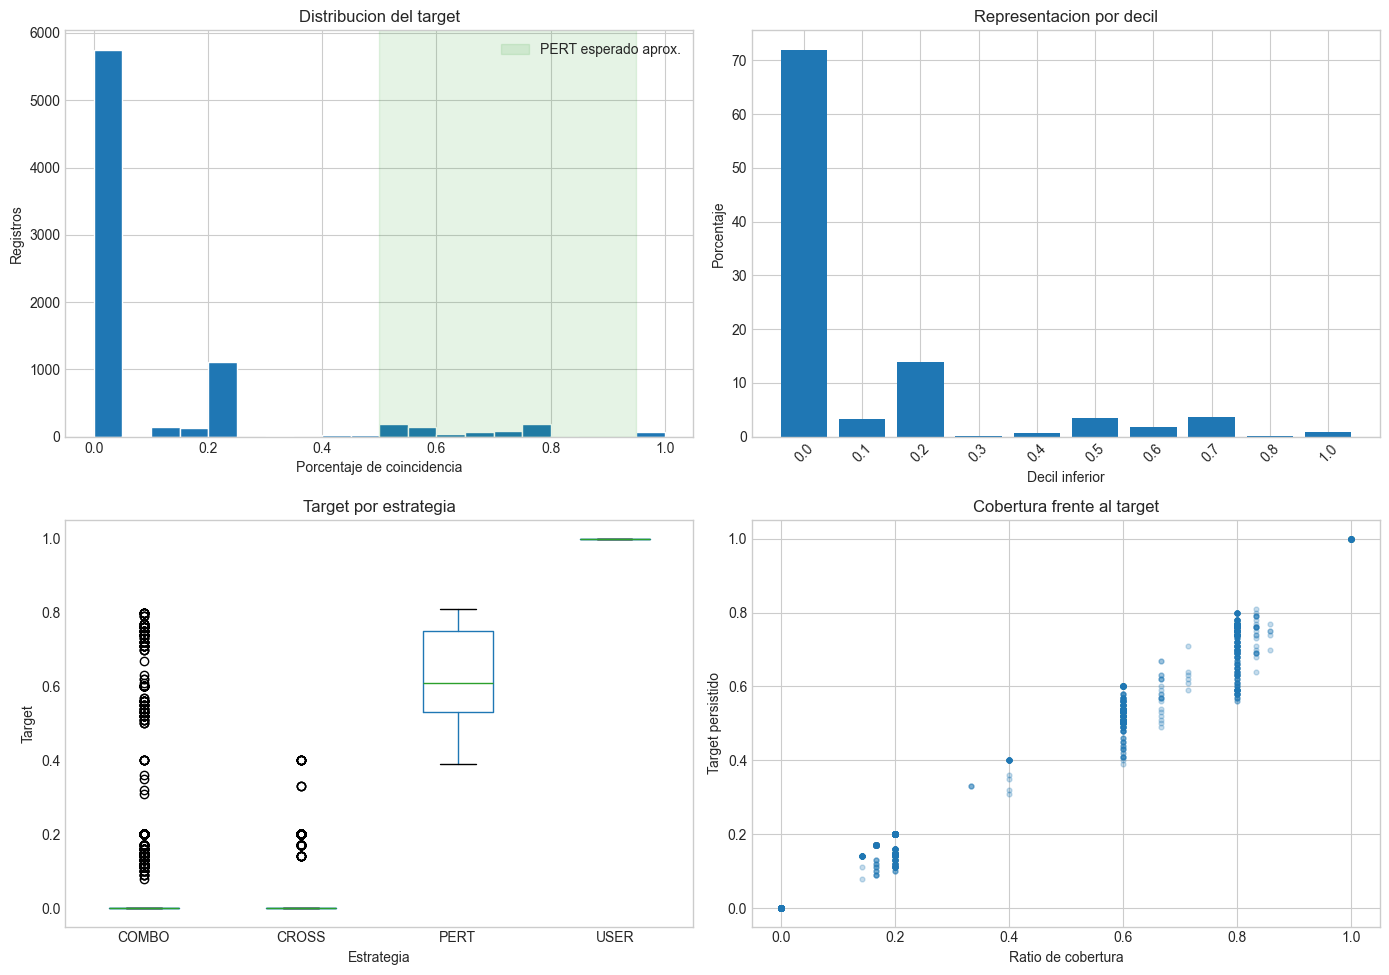

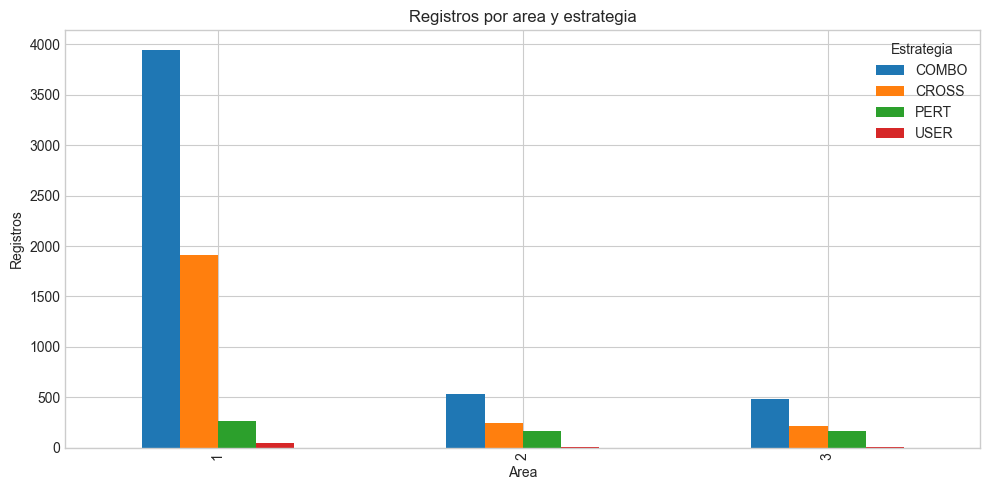

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['target_persistido'].dropna(), bins=np.linspace(0, 1, 21), edgecolor='white')
axes[0, 0].axvspan(0.50, 0.95, alpha=0.12, color='tab:green', label='PERT esperado aprox.')
axes[0, 0].set(title='Distribucion del target', xlabel='Porcentaje de coincidencia', ylabel='Registros')
axes[0, 0].legend()

axes[0, 1].bar(deciles['decil'].map(lambda value: f'{value:.1f}'), deciles['porcentaje'], color='tab:blue')
axes[0, 1].set(title='Representacion por decil', xlabel='Decil inferior', ylabel='Porcentaje')
axes[0, 1].tick_params(axis='x', rotation=45)

strategy_order = [x for x in ['USER', 'CROSS', 'PERT', 'COMBO', 'OTRA'] if x in df['estrategia'].unique()]
df.boxplot(column='target_persistido', by='estrategia', ax=axes[1, 0], grid=False)
axes[1, 0].set(title='Target por estrategia', xlabel='Estrategia', ylabel='Target')
axes[1, 0].figure.suptitle('')

axes[1, 1].scatter(df['ratio_cobertura'], df['target_persistido'], alpha=0.25, s=12)
axes[1, 1].set(title='Cobertura frente al target', xlabel='Ratio de cobertura', ylabel='Target persistido')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'dataset_validation_overview.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
area_strategy = prefix_counts.pivot(index='id_area', columns='estrategia', values='registros').fillna(0)
area_strategy.plot(kind='bar', ax=ax)
ax.set(title='Registros por area y estrategia', xlabel='Area', ylabel='Registros')
ax.legend(title='Estrategia')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'dataset_validation_coverage.png', dpi=160)
plt.show()

In [7]:
pert = df.loc[df['estrategia'] == 'PERT', 'target_persistido']
combo = df.loc[df['estrategia'] == 'COMBO', 'target_persistido']
pert_ok = bool(len(pert) and pert.min() >= 0.50 and pert.max() <= 0.95)
combo_ok = bool(len(combo) and combo.max() <= 0.80 and (combo >= 0.30).mean() >= 0.20)
criteria = pd.DataFrame([
    {'criterio': 'Target recomputable con precision NUMERIC(5,2)', 'estado': 'CUMPLE' if checks['targets_con_diferencia_mayor_0_005'].empty else 'NO CUMPLE'},
    {'criterio': 'Cumplimientos dentro de [0, 1]', 'estado': 'CUMPLE' if checks['cumplimientos_fuera_de_rango'].empty else 'NO CUMPLE'},
    {'criterio': 'No hay duplicados usuario-habilidad', 'estado': 'CUMPLE' if checks['duplicados_usuario_habilidad'].empty else 'NO CUMPLE'},
    {'criterio': 'Resultados respetan el area del usuario', 'estado': 'CUMPLE' if checks['resultados_fuera_area'].empty else 'NO CUMPLE'},
    {'criterio': 'Todos los resultados tienen usuario', 'estado': 'CUMPLE' if checks['resultados_sin_usuario'].empty else 'NO CUMPLE'},
    {'criterio': 'PERT en rango aproximado 0.50-0.95', 'estado': 'CUMPLE' if pert_ok else 'NO CUMPLE'},
    {'criterio': 'COMBO cubre rango medio sin superar 0.80', 'estado': 'CUMPLE' if combo_ok else 'REVISAR'},
    {'criterio': 'Balanceo por deciles', 'estado': 'DESCRIPTIVO; sin cuota exacta definida'},
])
display(criteria)

for table, value in {
    'stats_global': stats_global,
    'stats_strategy': stats_strategy,
    'stats_area': stats_area,
    'prefix_counts': prefix_counts,
    'deciles': deciles,
    'checks': check_summary,
    'criteria': criteria,
}.items():
    value.to_csv(OUTPUT_DIR / f'{table}.csv', index=False)

pert_min, pert_max = pert.min(), pert.max()
combo_zero_pct = (combo == 0).mean() * 100
summary = (
    '# Resultado de auditoria\n\n'
    f'- Registros analizados: {len(df):,}\n'
    f'- Conteos: USER={len(df[df["estrategia"] == "USER"]):,}, CROSS={len(df[df["estrategia"] == "CROSS"]):,}, PERT={len(pert):,}, COMBO={len(combo):,}\n'
    '- Integridad: sin errores en las seis comprobaciones ejecutadas.\n'
    f'- PERT observado: {pert_min:.2f} a {pert_max:.2f}; queda por debajo del rango esperado en la cola inferior.\n'
    f'- COMBO: {combo_zero_pct:.2f}% de ceros; requiere revisar el balanceo si se busca densidad media.\n'
    '- Distribucion global: 74.78% de los resultados esta en el decil 0.0 y 0.86% en 1.0.\n\n'
    'Conclusion: la persistencia y las relaciones son consistentes, pero la distribucion no esta balanceada y PERT no cubre completamente el rango prometido.\n'
    'No es necesario ejecutar dataset_generator.ipynb para esta validacion; debe ejecutarse despues solo para preparar features y el split de ML.\n\n'
    f'- Graficos y tablas: `{OUTPUT_DIR}`\n'
)
(OUTPUT_DIR / 'summary.md').write_text(summary, encoding='utf-8')
print(summary)

,criterio,estado
0,"Target recomputable con precision NUMERIC(5,2)",CUMPLE
1,"Cumplimientos dentro de [0, 1]",CUMPLE
2,No hay duplicados usuario-habilidad,CUMPLE
3,Resultados respetan el area del usuario,CUMPLE
4,Todos los resultados tienen usuario,CUMPLE
5,PERT en rango aproximado 0.50-0.95,NO CUMPLE
6,COMBO cubre rango medio sin superar 0.80,REVISAR
7,Balanceo por deciles,DESCRIPTIVO; sin cuota exacta definida


# Resultado de auditoria

- Registros analizados: 7,997
- Conteos: USER=66, CROSS=2,378, PERT=599, COMBO=4,954
- Integridad: sin errores en las seis comprobaciones ejecutadas.
- PERT observado: 0.39 a 0.81; queda por debajo del rango esperado en la cola inferior.
- COMBO: 79.47% de ceros; requiere revisar el balanceo si se busca densidad media.
- Distribucion global: 74.78% de los resultados esta en el decil 0.0 y 0.86% en 1.0.

Conclusion: la persistencia y las relaciones son consistentes, pero la distribucion no esta balanceada y PERT no cubre completamente el rango prometido.
No es necesario ejecutar dataset_generator.ipynb para esta validacion; debe ejecutarse despues solo para preparar features y el split de ML.

- Graficos y tablas: `C:\Users\emanu\Documents\METODOLOGIA\Athena\Reports\dataset_validation`

